**Criar estruturas matemáticas básicas com NumPy e imprimir seus shapes. O objetivo é treinar a leitura de dimensões.**

In [6]:
import numpy as np  # Importa a biblioteca NumPy e utiliza o apelido "np"

escalar = np.array(7.5)            # Cria um array NumPy escalar, ou seja, um único valor sem dimensões
vetor = np.array([1.0, 2.0, 3.0])  # Cria um vetor unidimensional contendo 3 valores
matriz = np.array([[1, 2, 3],      # Cria uma matriz bidimensional com 2 linhas e 3 colunas
                   [4, 5, 6]])     # Define a segunda linha da matriz
tensor = np.zeros((2, 4, 4, 3))    # Cria um tensor 4D preenchido com zeros, com formato (2, 4, 4, 3)

print('Escalar:', escalar.shape)   # Exibe o formato do escalar; resultado esperado: ()
print('Vetor:', vetor.shape)       # Exibe o formato do vetor; resultado esperado: (3,)
print('Matriz:', matriz.shape)     # Exibe o formato da matriz; resultado esperado: (2, 3)
print('Tensor:', tensor.shape)     # Exibe o formato do tensor; resultado esperado: (2, 4, 4, 3)

Escalar: ()
Vetor: (3,)
Matriz: (2, 3)
Tensor: (2, 4, 4, 3)


**Simular um neurônio artificial usando produto escalar, bias e função sigmoid.**

In [2]:
x = np.array([0.8, 0.1, 0.4])           # Define as entradas do neurônio
w = np.array([0.5, -0.2, 0.3])          # Define os pesos associados a cada entrada
b = -0.1                                # Define o bias, valor adicional usado para ajustar a ativação do neurônio

z = np.dot(x, w) + b                    # Calcula a soma ponderada das entradas pelos pesos e adiciona o bias
saida = 1 / (1 + np.exp(-z))            # Aplica a função sigmoid, transformando z em um valor entre 0 e 1

print('z:', round(z, 4))                 # Exibe o valor de z arredondado para 4 casas decimais
print('saida sigmoid:', round(saida, 4)) # Exibe a saída da sigmoid arredondada para 4 casas decimais

z: 0.4
saida sigmoid: 0.5987


**Comparar ReLU, sigmoid e softmax. O objetivo é visualizar como scores são transformados em saídas úteis.**

In [3]:
def relu(x):                                          # Define a função de ativação ReLU, que recebe x como entrada
    return np.maximum(0, x)                           # Retorna 0 para valores negativos e mantém valores positivos

def sigmoid(x):                                       # Define a função de ativação Sigmoid
    return 1 / (1 + np.exp(-x))                       # Transforma cada valor de x em um número entre 0 e 1

def softmax(z):                                       # Define a função Softmax para transformar logits em probabilidades
    exp = np.exp(z - np.max(z))                       # Calcula exponenciais após subtrair o maior valor para estabilidade numérica
    return exp / exp.sum()                            # Divide cada exponencial pela soma total, fazendo as probabilidades somarem 1

valores = np.array([-2.0, 0.0, 3.0])                 # Valores usados para testar as funções ReLU e Sigmoid
logits = np.array([1.2, 0.2, 2.1])                   # Scores brutos de três classes usados como entrada da Softmax

print('ReLU:', relu(valores))                         # Aplica ReLU aos valores e exibe o resultado
print('Sigmoid:', np.round(sigmoid(valores), 4))      # Aplica Sigmoid e arredonda os resultados para 4 casas decimais
print('Softmax:', np.round(softmax(logits), 4))       # Aplica Softmax aos logits e exibe as probabilidades com 4 casas decimais

ReLU: [0. 0. 3.]
Sigmoid: [0.1192 0.5    0.9526]
Softmax: [0.2613 0.0961 0.6426]


**Ajustar uma reta simples y = wx + b. A cada iteração, a perda é calculada e os parâmetros são atualizados.**

In [4]:
x = np.array([0, 1, 2, 3, 4], dtype=float)  # Define os valores de entrada x como números reais
y = 2 * x + 1                               # Cria os valores esperados usando a relação y = 2x + 1

w, b = -1.0, 0.0                            # Inicializa o peso w e o bias b com valores propositalmente incorretos
lr = 0.05                                   # Define a taxa de aprendizado usada para atualizar w e b
losses = []                                 # Cria uma lista para armazenar o erro de cada época

for epoca in range(80):                     # Repete o processo de treinamento durante 80 épocas
    y_pred = w * x + b                      # Calcula as previsões atuais do modelo usando y_pred = wx + b
    erro = y_pred - y                       # Calcula a diferença entre a previsão e o valor verdadeiro
    loss = np.mean(erro ** 2)               # Calcula o erro quadrático médio (MSE)
    losses.append(loss)                     # Armazena o valor da loss para acompanhar a evolução do treinamento

    dw = 2 * np.mean(erro * x)              # Calcula o gradiente da loss em relação ao peso w
    db = 2 * np.mean(erro)                  # Calcula o gradiente da loss em relação ao bias b
    w = w - lr * dw                         # Atualiza o peso w na direção que reduz o erro
    b = b - lr * db                         # Atualiza o bias b na direção que reduz o erro

print('w:', round(w, 3))                    # Exibe o peso aprendido, esperado próximo de 2
print('b:', round(b, 3))                    # Exibe o bias aprendido, esperado próximo de 1
print('loss final:', round(losses[-1], 4))  # Exibe o erro final do treinamento

w: 1.999
b: 1.004
loss final: 0.0


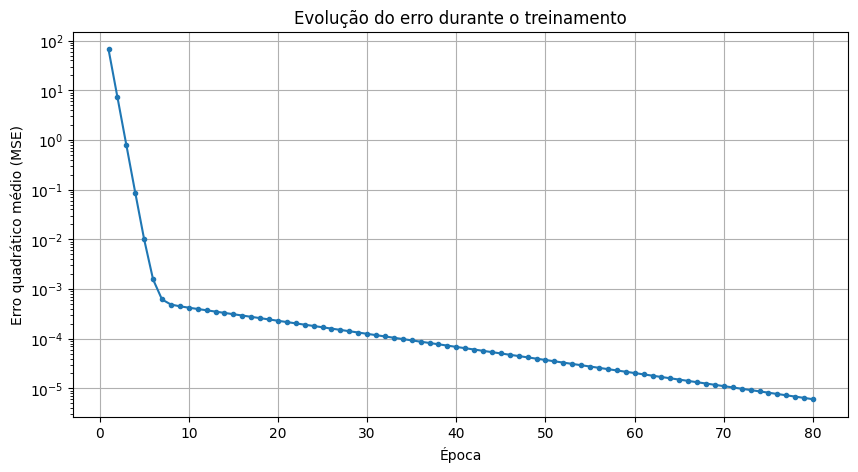

In [5]:
import matplotlib.pyplot as plt                        # Importa a biblioteca usada para criar gráficos

epocas = np.arange(1, len(losses) + 1)                 # Cria a sequência de épocas: 1, 2, 3, ..., 80

plt.figure(figsize=(10, 5))                            # Cria uma figura com 10 polegadas de largura e 5 de altura
plt.plot(epocas, losses, marker='o', markersize=3)     # Desenha a curva da loss em cada época
plt.xlabel('Época')                                    # Define o nome do eixo X
plt.ylabel('Erro quadrático médio (MSE)')              # Define o nome do eixo Y
plt.title('Evolução do erro durante o treinamento')    # Define o título do gráfico
plt.yscale('log')                                      # Usa escala logarítmica para visualizar melhor a queda do erro
plt.grid(True)                                         # Adiciona uma grade para facilitar a leitura
plt.show()